# SNP-BINN Pipeline with Clinical Data
# 
# This notebook runs the SNP-BINN pipeline with clinical patient data and analyzes results.

In [14]:
import numpy as np
import pandas as pd
import json
from scipy import sparse
from binn import BINN, BINNDataLoader, BINNTrainer, BINNExplainer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Step 1 load data

In [15]:
def load_data():
    # Load genotype data
    loaded = np.load('dummy_genotype_matrix.npz', allow_pickle=True)
    genotype_matrix = loaded['matrix']
    snps = loaded['snps']
    
    # Load gene index
    with open('gene_index.json', 'r') as f:
        gene_index = json.load(f)
    gene_names = list(gene_index.keys())
    
    # Load SNP-gene mapping
    sparse_loaded = np.load('sparse_matrix.npz', allow_pickle=True)
    if 'data' in sparse_loaded.keys():
        snp_to_gene = sparse.csr_matrix(
            (sparse_loaded['data'], sparse_loaded['indices'], sparse_loaded['indptr']),
            shape=tuple(sparse_loaded['shape'])
        )
    else:
        snp_to_gene = sparse_loaded['matrix']
    
    print(f"Loaded: {genotype_matrix.shape[0]} patients, {len(snps)} SNPs, {len(gene_names)} genes")
    return genotype_matrix, snps, gene_names, snp_to_gene



Loaded: 50 patients, 100 SNPs, 122 genes


# Execute Load Data step 1

In [18]:
genotype_matrix, snps, gene_names, snp_to_gene = load_data()

Loaded: 50 patients, 100 SNPs, 122 genes


# Prepare SNP data for BINN

In [19]:
sample_names = [f"Patient_{i}" for i in range(genotype_matrix.shape[0])]

snp_data = pd.DataFrame(
    genotype_matrix.T,
    index=snps,
    columns=sample_names
).reset_index().rename(columns={'index': 'SNP'})

print(f"SNP data prepared: {snp_data.shape}")

SNP data prepared: (100, 51)


# Create SNP-gene mapping


In [20]:
coo_matrix = snp_to_gene.tocoo()
snp_gene_mappings = []
for snp_idx, gene_idx in zip(coo_matrix.row, coo_matrix.col):
    snp_gene_mappings.append({
        'input': snps[snp_idx],
        'translation': gene_names[gene_idx]
    })
snp_gene_mapping_df = pd.DataFrame(snp_gene_mappings)
print(f"Created {len(snp_gene_mapping_df)} SNP-gene mappings")

Created 130 SNP-gene mappings


# Create gene-pathway mapping

In [22]:
gene_to_pathway = []
with open('ReactomePathways.gmt', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            reactome_id = parts[1]
            genes = parts[2:]
            for gene in genes:
                gene_to_pathway.append({
                    'input': gene,
                    'translation': reactome_id
                })

gene_pathway_mapping_df = pd.DataFrame(gene_to_pathway)
print(f"Created {len(gene_pathway_mapping_df)} gene-pathway mappings")

Created 135371 gene-pathway mappings


# Load pathway hierarchy

In [23]:
pathways_df = pd.read_csv('reactome_pathways_relation_2025_01_14.txt', sep='\t', header=None)
pathways_df.columns = ['source', 'target']
print(f"Loaded {len(pathways_df)} pathway connections")

Loaded 22746 pathway connections


# Generate clinical data


In [24]:
def generate_clinical_data(sample_names):
    n_patients = len(sample_names)
    np.random.seed(42)
    
    # Basic demographics
    ages = np.clip(np.random.normal(65, 15, n_patients).astype(int), 30, 90)
    genders = np.random.choice(['Male', 'Female'], n_patients, p=[0.6, 0.4])
    
    # Disease status
    disease_status = np.random.choice(
        ['MI', 'Atherosclerosis', 'Control'], 
        n_patients, 
        p=[0.15, 0.15, 0.7]
    )
    
    # Clinical measurements correlated with disease
    base_cholesterol = np.random.normal(200, 40, n_patients)
    disease_effect = np.where(disease_status != 'Control', 
                             np.random.normal(50, 20, n_patients), 
                             np.random.normal(0, 10, n_patients))
    total_cholesterol = np.clip(base_cholesterol + disease_effect, 120, 400)
    
    base_bp = np.random.normal(130, 20, n_patients)
    bp_effect = np.where(disease_status != 'Control', 
                        np.random.normal(20, 10, n_patients), 
                        np.random.normal(0, 5, n_patients))
    systolic_bp = np.clip(base_bp + bp_effect, 90, 200)
    
    base_bmi = np.random.normal(27, 5, n_patients)
    bmi_effect = np.where(disease_status != 'Control', 3, 0)
    bmi = np.clip(base_bmi + bmi_effect, 18, 45)
    
    # Risk factors
    smoking_prob = np.where(disease_status != 'Control', 0.7, 0.3)
    smoking_history = np.random.binomial(1, smoking_prob, n_patients)
    
    diabetes_prob = np.where(disease_status != 'Control', 0.4, 0.1)
    diabetes = np.random.binomial(1, diabetes_prob, n_patients)
    
    clinical_data = pd.DataFrame({
        'patient_id': sample_names,
        'age': ages,
        'gender': genders,
        'disease_status': disease_status,
        'total_cholesterol': np.round(total_cholesterol, 1),
        'systolic_bp': systolic_bp.astype(int),
        'bmi': np.round(bmi, 1),
        'smoking_history': smoking_history.astype(bool),
        'diabetes': diabetes.astype(bool)
    })
    
    return clinical_data

clinical_data = generate_clinical_data(sample_names)
print(f"Generated clinical data for {len(clinical_data)} patients")
print(f"Disease distribution: {clinical_data['disease_status'].value_counts().to_dict()}")

Generated clinical data for 50 patients
Disease distribution: {'Control': 34, 'Atherosclerosis': 9, 'MI': 7}


# Create design matrix for BINN


In [25]:
design_matrix = pd.DataFrame({
    'sample': clinical_data['patient_id'],
    'group': clinical_data['disease_status']
})

print("Design matrix created for BINN training")

Design matrix created for BINN training


# Create BINN model

In [26]:
gene_pathway_edges = []
for _, row in gene_pathway_mapping_df.iterrows():
    gene_pathway_edges.append({
        'source': row['input'],
        'target': row['translation']
    })

gene_pathway_df = pd.DataFrame(gene_pathway_edges)
extended_pathways_df = pd.concat([gene_pathway_df, pathways_df], ignore_index=True)

binn = BINN(
    data_matrix=snp_data,
    mapping=snp_gene_mapping_df,
    pathways=extended_pathways_df,
    entity_col='SNP',
    input_col='input',
    translation_col='translation',
    source_col='source',
    target_col='target',
    n_layers=4,
    n_outputs=3,
    dropout=0.2,
    device='cpu'
)

print(f"BINN created with {len(binn.connectivity_matrices)} layers")



[INFO] BINN is on device: cpu
BINN created with 5 layers


# Train BINN model

In [27]:
dataloader = BINNDataLoader(binn)
dataloaders = dataloader.create_dataloaders(
    data_matrix=snp_data,
    design_matrix=design_matrix,
    feature_column="SNP",
    group_column="group",
    sample_column="sample",
    batch_size=8,
    validation_split=0.2
)

trainer = BINNTrainer(binn)
trainer.fit(dataloaders=dataloaders, num_epochs=10)

print("BINN training completed")

Mapping group labels: {'Atherosclerosis': 0, 'Control': 1, 'MI': 2}
[Epoch 1/10] Train Loss: 1.1176, Train Accuracy: 0.4000
[Epoch 1/10] Val Loss: 1.0902, Val Accuracy: 0.6250
[Epoch 2/10] Train Loss: 1.1542, Train Accuracy: 0.3750
[Epoch 2/10] Val Loss: 1.0825, Val Accuracy: 0.6250
[Epoch 3/10] Train Loss: 1.0328, Train Accuracy: 0.4500
[Epoch 3/10] Val Loss: 1.0742, Val Accuracy: 0.6250
[Epoch 4/10] Train Loss: 1.0558, Train Accuracy: 0.4250
[Epoch 4/10] Val Loss: 1.0666, Val Accuracy: 0.6250
[Epoch 5/10] Train Loss: 1.1025, Train Accuracy: 0.4000
[Epoch 5/10] Val Loss: 1.0586, Val Accuracy: 0.6250
[Epoch 6/10] Train Loss: 1.1169, Train Accuracy: 0.4000
[Epoch 6/10] Val Loss: 1.0524, Val Accuracy: 0.6250
[Epoch 7/10] Train Loss: 1.0740, Train Accuracy: 0.2750
[Epoch 7/10] Val Loss: 1.0457, Val Accuracy: 0.6250
[Epoch 8/10] Train Loss: 1.0724, Train Accuracy: 0.4000
[Epoch 8/10] Val Loss: 1.0381, Val Accuracy: 0.6250
[Epoch 9/10] Train Loss: 0.9474, Train Accuracy: 0.5250
[Epoch 9/10]

# Interpret model


In [28]:
explainer = BINNExplainer(binn)
explanations = explainer.explain_single(
    dataloaders,
    split="val",
    normalization_method="subgraph"
)

print(f"Generated {len(explanations)} feature explanations")

# %%
# ANALYSIS: Results summary
print("SNP-BINN Pipeline Results:")
print("=" * 40)
print(f"Model input features: {len(binn.inputs)}")
print(f"Network layers: {len(binn.connectivity_matrices)}")
print(f"Total parameters: {sum(p.numel() for p in binn.parameters()):,}")
print(f"Explanations generated: {len(explanations)}")
print("\nPipeline Status: COMPLETED SUCCESSFULLY")

# Layer connectivity
print("\nLayer Connectivity:")
for i, matrix in enumerate(binn.connectivity_matrices):
    connections = matrix.sum().sum()
    density = connections / (matrix.shape[0] * matrix.shape[1]) * 100
    print(f"  Layer {i}: {matrix.shape[0]}→{matrix.shape[1]} ({connections:.0f} connections, {density:.1f}% density)")

# %%
# ANALYSIS: Top genetic features
if len(explanations) > 0:
    top_features = (
        explanations
        .groupby('source_node')['importance']
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )
    
    print("\nTop 15 Important Genetic Features:")
    for i, (feature, importance) in enumerate(top_features.items(), 1):
        print(f"  {i:2d}. {feature}: {importance:.4f}")

# %%
# ANALYSIS: Clinical data summary
print("\nClinical Data Analysis:")
print("-" * 25)

# Disease distribution
disease_counts = clinical_data['disease_status'].value_counts()
print(f"Total patients: {len(clinical_data)}")
for disease, count in disease_counts.items():
    print(f"  {disease}: {count} ({count/len(clinical_data)*100:.1f}%)")

# Clinical characteristics by disease
print(f"\nClinical characteristics by disease:")
clinical_summary = clinical_data.groupby('disease_status').agg({
    'age': 'mean',
    'total_cholesterol': 'mean',
    'systolic_bp': 'mean',
    'bmi': 'mean',
    'smoking_history': 'mean',
    'diabetes': 'mean'
}).round(2)

print(clinical_summary)


Generated 13269 feature explanations
SNP-BINN Pipeline Results:
Model input features: 49
Network layers: 5
Total parameters: 1,338,851
Explanations generated: 13269

Pipeline Status: COMPLETED SUCCESSFULLY

Layer Connectivity:
  Layer 0: 49→52 (63 connections, 2.5% density)
  Layer 1: 52→138 (124 connections, 1.7% density)
  Layer 2: 138→674 (464 connections, 0.5% density)
  Layer 3: 674→1814 (1958 connections, 0.2% density)
  Layer 4: 1814→1 (1814 connections, 100.0% density)

Top 15 Important Genetic Features:
   1. VAV3: 1.9745
   2. GNAI3: 1.1679
   3. R-HSA-9012999: 0.8923
   4. FMOD: 0.6819
   5. PRELP: 0.6807
   6. CDC7: 0.5446
   7. LAMC1: 0.5153
   8. CHRM3: 0.4336
   9. RHOU: 0.3837
  10. MEF2D: 0.3740
  11. R-HSA-1483206: 0.3304
  12. R-HSA-3560782: 0.3125
  13. R-HSA-9006115: 0.3059
  14. R-HSA-3108232: 0.1967
  15. R-HSA-3781860: 0.1944

Clinical Data Analysis:
-------------------------
Total patients: 50
  Control: 34 (68.0%)
  Atherosclerosis: 9 (18.0%)
  MI: 7 (14.0%)



# VISUALIZATION: Network architecture

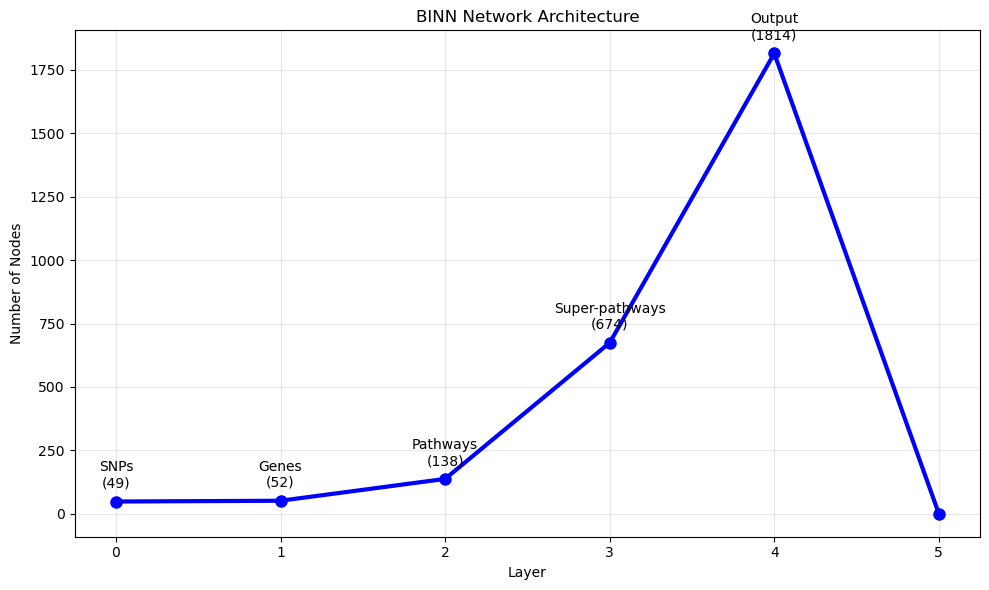

In [30]:
layer_sizes = [binn.connectivity_matrices[0].shape[0]] + [matrix.shape[1] for matrix in binn.connectivity_matrices]

plt.figure(figsize=(10, 6))
plt.plot(range(len(layer_sizes)), layer_sizes, 'o-', linewidth=3, markersize=8, color='blue')
plt.title('BINN Network Architecture')
plt.xlabel('Layer')
plt.ylabel('Number of Nodes')
plt.grid(True, alpha=0.3)

layer_labels = ['SNPs', 'Genes', 'Pathways', 'Super-pathways', 'Output']
for i, (size, label) in enumerate(zip(layer_sizes, layer_labels)):
    if i < len(layer_labels):
        plt.annotate(f'{label}\n({size})', (i, size), 
                    textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

# VISUALIZATION: Feature importance

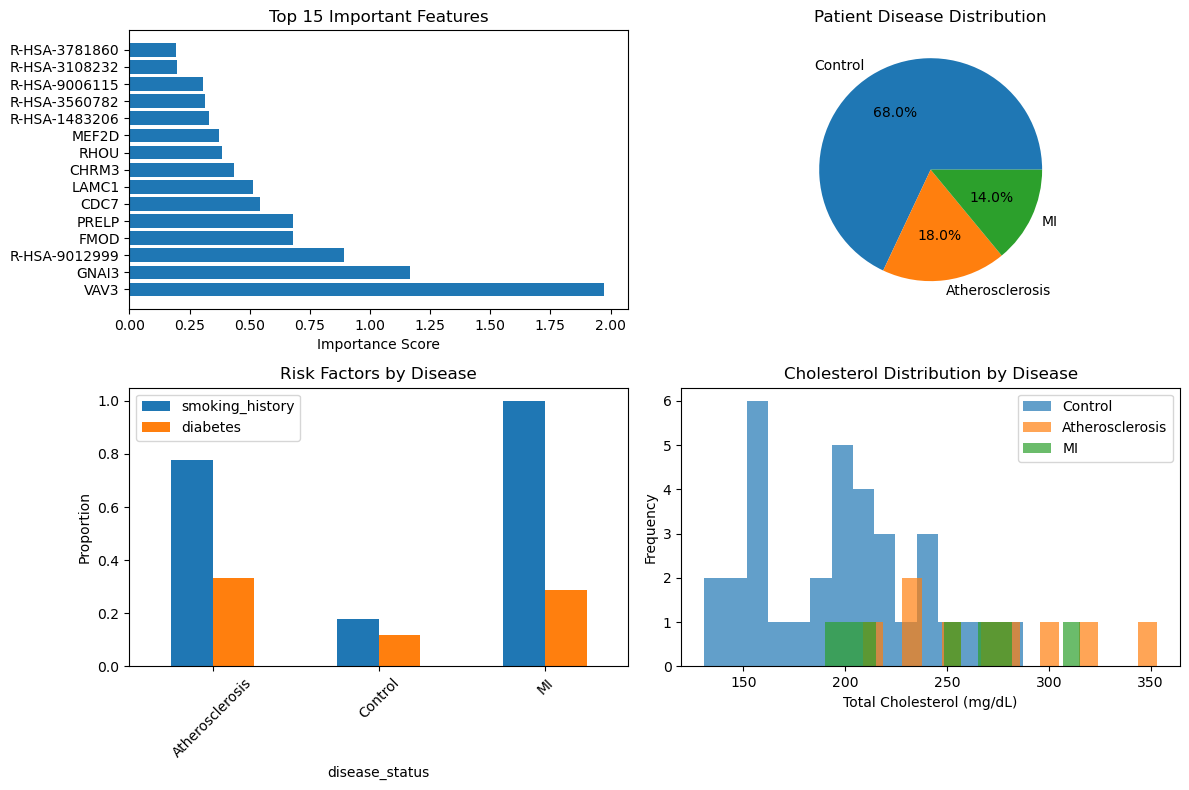

In [29]:
if len(explanations) > 0:
    plt.figure(figsize=(12, 8))
    
    # Top features bar plot
    plt.subplot(2, 2, 1)
    top_features = explanations.groupby('source_node')['importance'].sum().sort_values(ascending=False).head(15)
    plt.barh(range(len(top_features)), top_features.values)
    plt.yticks(range(len(top_features)), top_features.index)
    plt.title('Top 15 Important Features')
    plt.xlabel('Importance Score')
    
    # Disease distribution pie chart
    plt.subplot(2, 2, 2)
    disease_counts = clinical_data['disease_status'].value_counts()
    plt.pie(disease_counts.values, labels=disease_counts.index, autopct='%1.1f%%')
    plt.title('Patient Disease Distribution')
    
    # Clinical risk factors
    plt.subplot(2, 2, 3)
    risk_data = clinical_data.groupby('disease_status')[['smoking_history', 'diabetes']].mean()
    risk_data.plot(kind='bar', ax=plt.gca())
    plt.title('Risk Factors by Disease')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend()
    
    # Cholesterol distribution
    plt.subplot(2, 2, 4)
    for disease in clinical_data['disease_status'].unique():
        data = clinical_data[clinical_data['disease_status'] == disease]['total_cholesterol']
        plt.hist(data, alpha=0.7, label=disease, bins=15)
    plt.title('Cholesterol Distribution by Disease')
    plt.xlabel('Total Cholesterol (mg/dL)')
    plt.ylabel('Frequency')
    plt.legend()
    
    plt.tight_layout()
    plt.show()


SNP data prepared: (100, 51)
Created 130 SNP-gene mappings
Created 135371 gene-pathway mappings
Loaded 22746 pathway connections
Generated clinical data for 50 patients
Disease distribution: {'Control': 34, 'Atherosclerosis': 9, 'MI': 7}
Design matrix created for BINN training

[INFO] BINN is on device: cpu
BINN created with 5 layers
Mapping group labels: {'Atherosclerosis': 0, 'Control': 1, 'MI': 2}
[Epoch 1/10] Train Loss: 1.1648, Train Accuracy: 0.3500
[Epoch 1/10] Val Loss: 1.0943, Val Accuracy: 0.6250
[Epoch 2/10] Train Loss: 1.1999, Train Accuracy: 0.3000
[Epoch 2/10] Val Loss: 1.0865, Val Accuracy: 0.6250
[Epoch 3/10] Train Loss: 1.1029, Train Accuracy: 0.3500
[Epoch 3/10] Val Loss: 1.0790, Val Accuracy: 0.6250
[Epoch 4/10] Train Loss: 1.1512, Train Accuracy: 0.3750
[Epoch 4/10] Val Loss: 1.0718, Val Accuracy: 0.6250
[Epoch 5/10] Train Loss: 1.1490, Train Accuracy: 0.3000
[Epoch 5/10] Val Loss: 1.0647, Val Accuracy: 0.6250
[Epoch 6/10] Train Loss: 1.0640, Train Accuracy: 0.3500


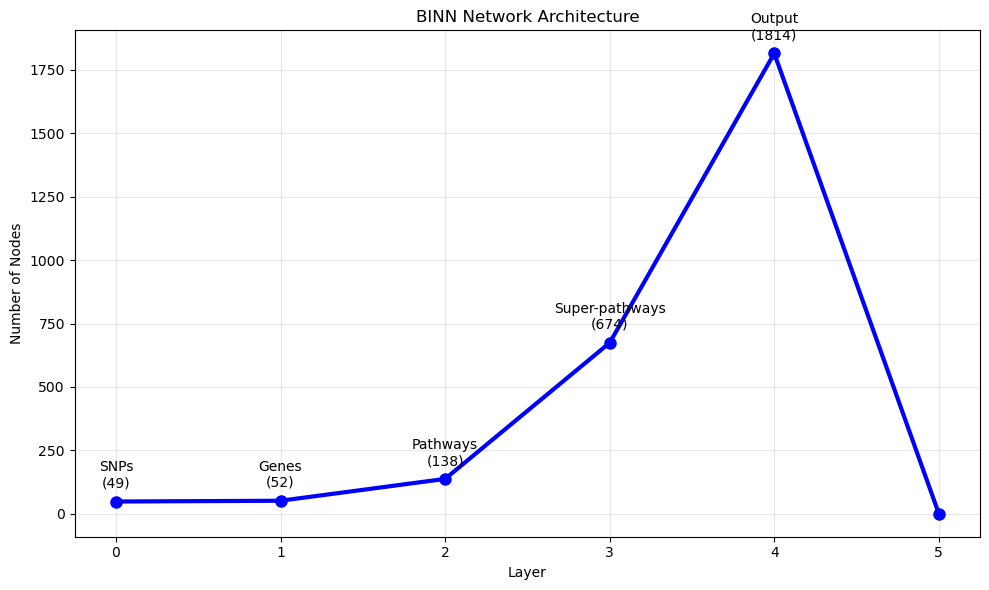

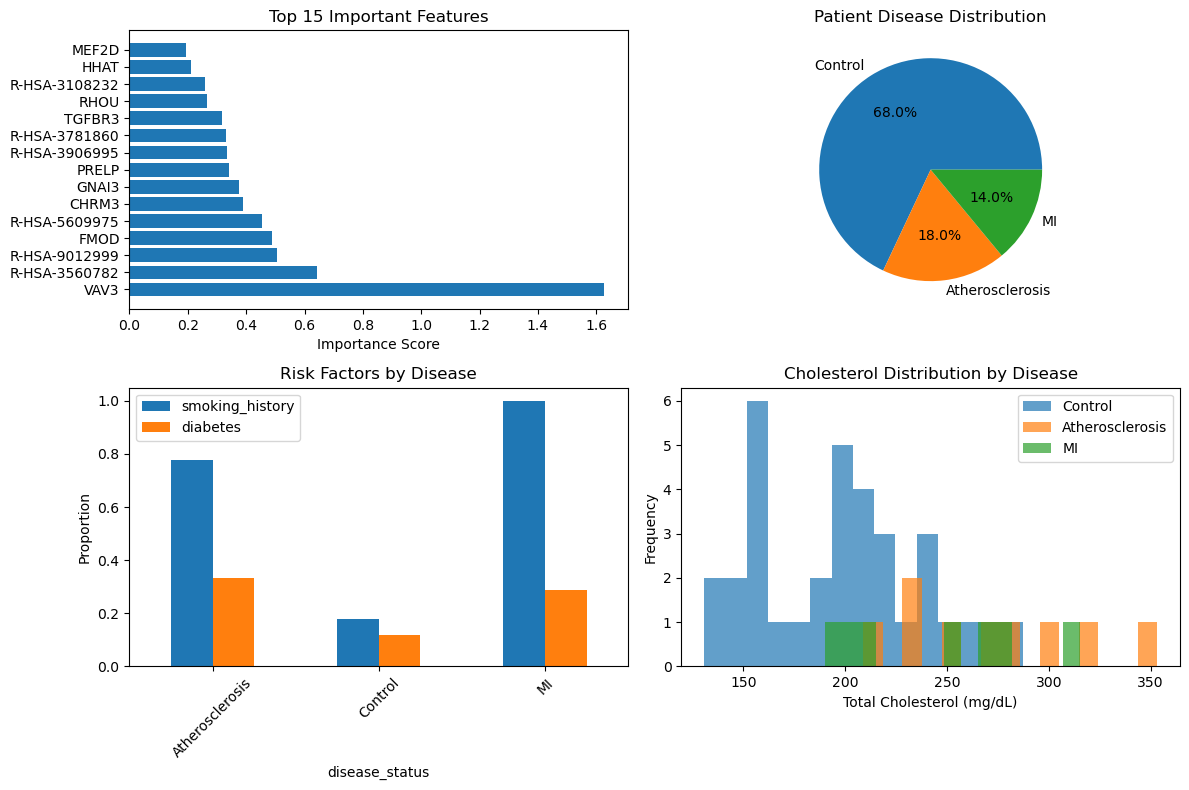


Biomarker Discovery Results:
Top SNP candidates: 0
Top gene candidates: 13
  Examples: ['VAV3', 'FMOD', 'CHRM3', 'GNAI3', 'PRELP']
Top pathway candidates: 7
  Examples: ['R-HSA-3560782', 'R-HSA-9012999', 'R-HSA-5609975']

Pipeline completed successfully!
Results show integration of genetic and clinical data for cardiovascular disease prediction.


In [17]:
# %% [markdown]
# # Simple SNP-BINN Pipeline with Clinical Data
# 
# This notebook runs the SNP-BINN pipeline with clinical patient data and analyzes results.

# %%
import numpy as np
import pandas as pd
import json
from scipy import sparse
from binn import BINN, BINNDataLoader, BINNTrainer, BINNExplainer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# %%
# Step 1-7: Load and prepare genetic data (same as before)
def load_data():
    # Load genotype data
    loaded = np.load('dummy_genotype_matrix.npz', allow_pickle=True)
    genotype_matrix = loaded['matrix']
    snps = loaded['snps']
    
    # Load gene index
    with open('gene_index.json', 'r') as f:
        gene_index = json.load(f)
    gene_names = list(gene_index.keys())
    
    # Load SNP-gene mapping
    sparse_loaded = np.load('sparse_matrix.npz', allow_pickle=True)
    if 'data' in sparse_loaded.keys():
        snp_to_gene = sparse.csr_matrix(
            (sparse_loaded['data'], sparse_loaded['indices'], sparse_loaded['indptr']),
            shape=tuple(sparse_loaded['shape'])
        )
    else:
        snp_to_gene = sparse_loaded['matrix']
    
    print(f"Loaded: {genotype_matrix.shape[0]} patients, {len(snps)} SNPs, {len(gene_names)} genes")
    return genotype_matrix, snps, gene_names, snp_to_gene

genotype_matrix, snps, gene_names, snp_to_gene = load_data()

# %%
# Step 8: Prepare SNP data for BINN
sample_names = [f"Patient_{i}" for i in range(genotype_matrix.shape[0])]

snp_data = pd.DataFrame(
    genotype_matrix.T,
    index=snps,
    columns=sample_names
).reset_index().rename(columns={'index': 'SNP'})

print(f"SNP data prepared: {snp_data.shape}")

# %%
# Step 9: Create SNP-gene mapping
coo_matrix = snp_to_gene.tocoo()
snp_gene_mappings = []
for snp_idx, gene_idx in zip(coo_matrix.row, coo_matrix.col):
    snp_gene_mappings.append({
        'input': snps[snp_idx],
        'translation': gene_names[gene_idx]
    })
snp_gene_mapping_df = pd.DataFrame(snp_gene_mappings)
print(f"Created {len(snp_gene_mapping_df)} SNP-gene mappings")

# %%
# Step 10: Create gene-pathway mapping
gene_to_pathway = []
with open('ReactomePathways.gmt', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 3:
            reactome_id = parts[1]
            genes = parts[2:]
            for gene in genes:
                gene_to_pathway.append({
                    'input': gene,
                    'translation': reactome_id
                })

gene_pathway_mapping_df = pd.DataFrame(gene_to_pathway)
print(f"Created {len(gene_pathway_mapping_df)} gene-pathway mappings")

# %%
# Step 11: Load pathway hierarchy
pathways_df = pd.read_csv('reactome_pathways_relation_2025_01_14.txt', sep='\t', header=None)
pathways_df.columns = ['source', 'target']
print(f"Loaded {len(pathways_df)} pathway connections")

# %%
# Step 12: Generate clinical data
def generate_clinical_data(sample_names):
    n_patients = len(sample_names)
    np.random.seed(42)
    
    # Basic demographics
    ages = np.clip(np.random.normal(65, 15, n_patients).astype(int), 30, 90)
    genders = np.random.choice(['Male', 'Female'], n_patients, p=[0.6, 0.4])
    
    # Disease status
    disease_status = np.random.choice(
        ['MI', 'Atherosclerosis', 'Control'], 
        n_patients, 
        p=[0.15, 0.15, 0.7]
    )
    
    # Clinical measurements correlated with disease
    base_cholesterol = np.random.normal(200, 40, n_patients)
    disease_effect = np.where(disease_status != 'Control', 
                             np.random.normal(50, 20, n_patients), 
                             np.random.normal(0, 10, n_patients))
    total_cholesterol = np.clip(base_cholesterol + disease_effect, 120, 400)
    
    base_bp = np.random.normal(130, 20, n_patients)
    bp_effect = np.where(disease_status != 'Control', 
                        np.random.normal(20, 10, n_patients), 
                        np.random.normal(0, 5, n_patients))
    systolic_bp = np.clip(base_bp + bp_effect, 90, 200)
    
    base_bmi = np.random.normal(27, 5, n_patients)
    bmi_effect = np.where(disease_status != 'Control', 3, 0)
    bmi = np.clip(base_bmi + bmi_effect, 18, 45)
    
    # Risk factors
    smoking_prob = np.where(disease_status != 'Control', 0.7, 0.3)
    smoking_history = np.random.binomial(1, smoking_prob, n_patients)
    
    diabetes_prob = np.where(disease_status != 'Control', 0.4, 0.1)
    diabetes = np.random.binomial(1, diabetes_prob, n_patients)
    
    clinical_data = pd.DataFrame({
        'patient_id': sample_names,
        'age': ages,
        'gender': genders,
        'disease_status': disease_status,
        'total_cholesterol': np.round(total_cholesterol, 1),
        'systolic_bp': systolic_bp.astype(int),
        'bmi': np.round(bmi, 1),
        'smoking_history': smoking_history.astype(bool),
        'diabetes': diabetes.astype(bool)
    })
    
    return clinical_data

clinical_data = generate_clinical_data(sample_names)
print(f"Generated clinical data for {len(clinical_data)} patients")
print(f"Disease distribution: {clinical_data['disease_status'].value_counts().to_dict()}")

# %%
# Step 13: Create design matrix for BINN
design_matrix = pd.DataFrame({
    'sample': clinical_data['patient_id'],
    'group': clinical_data['disease_status']
})

print("Design matrix created for BINN training")

# %%

# %%


# %%
# Step 16: Interpret model
explainer = BINNExplainer(binn)
explanations = explainer.explain_single(
    dataloaders,
    split="val",
    normalization_method="subgraph"
)

print(f"Generated {len(explanations)} feature explanations")

# %%
# ANALYSIS: Results summary
print("SNP-BINN Pipeline Results:")
print("=" * 40)
print(f"Model input features: {len(binn.inputs)}")
print(f"Network layers: {len(binn.connectivity_matrices)}")
print(f"Total parameters: {sum(p.numel() for p in binn.parameters()):,}")
print(f"Explanations generated: {len(explanations)}")
print("\nPipeline Status: COMPLETED SUCCESSFULLY")

# Layer connectivity
print("\nLayer Connectivity:")
for i, matrix in enumerate(binn.connectivity_matrices):
    connections = matrix.sum().sum()
    density = connections / (matrix.shape[0] * matrix.shape[1]) * 100
    print(f"  Layer {i}: {matrix.shape[0]}→{matrix.shape[1]} ({connections:.0f} connections, {density:.1f}% density)")

# %%
# ANALYSIS: Top genetic features
if len(explanations) > 0:
    top_features = (
        explanations
        .groupby('source_node')['importance']
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )
    
    print("\nTop 15 Important Genetic Features:")
    for i, (feature, importance) in enumerate(top_features.items(), 1):
        print(f"  {i:2d}. {feature}: {importance:.4f}")

# %%
# ANALYSIS: Clinical data summary
print("\nClinical Data Analysis:")
print("-" * 25)

# Disease distribution
disease_counts = clinical_data['disease_status'].value_counts()
print(f"Total patients: {len(clinical_data)}")
for disease, count in disease_counts.items():
    print(f"  {disease}: {count} ({count/len(clinical_data)*100:.1f}%)")

# Clinical characteristics by disease
print(f"\nClinical characteristics by disease:")
clinical_summary = clinical_data.groupby('disease_status').agg({
    'age': 'mean',
    'total_cholesterol': 'mean',
    'systolic_bp': 'mean',
    'bmi': 'mean',
    'smoking_history': 'mean',
    'diabetes': 'mean'
}).round(2)

print(clinical_summary)

# %%
# VISUALIZATION: Network architecture
layer_sizes = [binn.connectivity_matrices[0].shape[0]] + [matrix.shape[1] for matrix in binn.connectivity_matrices]

plt.figure(figsize=(10, 6))
plt.plot(range(len(layer_sizes)), layer_sizes, 'o-', linewidth=3, markersize=8, color='blue')
plt.title('BINN Network Architecture')
plt.xlabel('Layer')
plt.ylabel('Number of Nodes')
plt.grid(True, alpha=0.3)

layer_labels = ['SNPs', 'Genes', 'Pathways', 'Super-pathways', 'Output']
for i, (size, label) in enumerate(zip(layer_sizes, layer_labels)):
    if i < len(layer_labels):
        plt.annotate(f'{label}\n({size})', (i, size), 
                    textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

# %%
# VISUALIZATION: Feature importance
if len(explanations) > 0:
    plt.figure(figsize=(12, 8))
    
    # Top features bar plot
    plt.subplot(2, 2, 1)
    top_features = explanations.groupby('source_node')['importance'].sum().sort_values(ascending=False).head(15)
    plt.barh(range(len(top_features)), top_features.values)
    plt.yticks(range(len(top_features)), top_features.index)
    plt.title('Top 15 Important Features')
    plt.xlabel('Importance Score')
    
    # Disease distribution pie chart
    plt.subplot(2, 2, 2)
    disease_counts = clinical_data['disease_status'].value_counts()
    plt.pie(disease_counts.values, labels=disease_counts.index, autopct='%1.1f%%')
    plt.title('Patient Disease Distribution')
    
    # Clinical risk factors
    plt.subplot(2, 2, 3)
    risk_data = clinical_data.groupby('disease_status')[['smoking_history', 'diabetes']].mean()
    risk_data.plot(kind='bar', ax=plt.gca())
    plt.title('Risk Factors by Disease')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend()
    
    # Cholesterol distribution
    plt.subplot(2, 2, 4)
    for disease in clinical_data['disease_status'].unique():
        data = clinical_data[clinical_data['disease_status'] == disease]['total_cholesterol']
        plt.hist(data, alpha=0.7, label=disease, bins=15)
    plt.title('Cholesterol Distribution by Disease')
    plt.xlabel('Total Cholesterol (mg/dL)')
    plt.ylabel('Frequency')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# %%
# ANALYSIS: Final biomarker candidates
if len(explanations) > 0:
    top_genetic = explanations.groupby('source_node')['importance'].sum().sort_values(ascending=False).head(20)
    
    snp_candidates = [f for f in top_genetic.index if f.startswith('rs')]
    gene_candidates = [f for f in top_genetic.index if not f.startswith('rs') and not f.startswith('R-HSA')]
    pathway_candidates = [f for f in top_genetic.index if f.startswith('R-HSA')]
    
    print("\nBiomarker Discovery Results:")
    print("=" * 30)
    print(f"Top SNP candidates: {len(snp_candidates)}")
    if snp_candidates:
        print(f"  Examples: {snp_candidates[:5]}")
    
    print(f"Top gene candidates: {len(gene_candidates)}")
    if gene_candidates:
        print(f"  Examples: {gene_candidates[:5]}")
    
    print(f"Top pathway candidates: {len(pathway_candidates)}")
    if pathway_candidates:
        print(f"  Examples: {pathway_candidates[:3]}")

print("\nPipeline completed successfully!")
print("Results show integration of genetic and clinical data for cardiovascular disease prediction.")

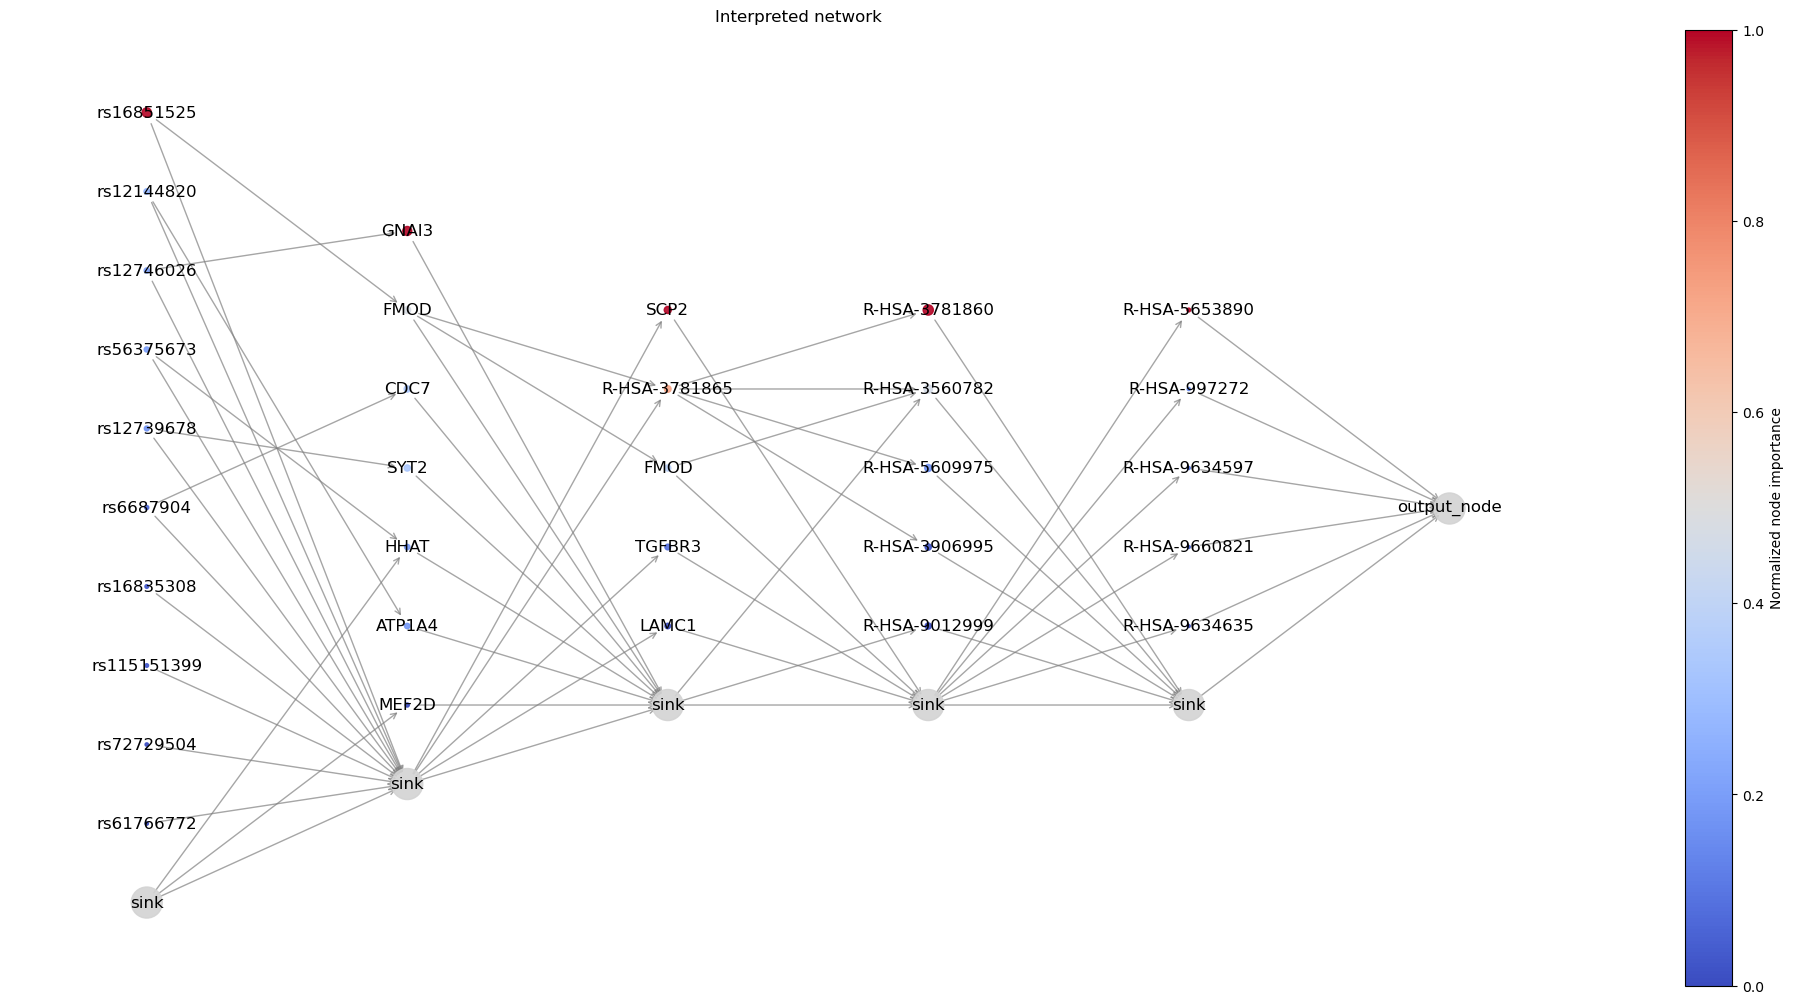

In [13]:
# @title ## 5. Plot
from binn.plot.network import visualize_binn

layer_specific_top_n = {"0": 10, "1": 7, "2": 5, "3": 5, "4": 5}

plt = visualize_binn(
    explanations,
    top_n=layer_specific_top_n,
    plot_size=(20, 10),
    sink_node_size=500,
    node_size_scaling=200,
    edge_width=1,
    node_cmap="coolwarm"
)

plt.title("Interpreted network")
plt.show()
     